In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import sqlalchemy
import psycopg2
import os

In [2]:
df = pd.read_csv('C:/Users/Chibueze/Valentine-Python-Project/PythonProject/Practical/Airbnb_Greece/data/raw/crete_greece.csv.gz', compression= 'gzip')


In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

In [4]:
df

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,27966,https://www.airbnb.com/rooms/27966,20250928035310,2025-09-28,city scrape,Heraklion-Pinelopi Apartment,For an unforgettable stay!! Just 10 minutes wa...,Ammoudara is a very cute area with lots of bea...,https://a0.muscache.com/pictures/b8e0ecb1-c444...,120502,https://www.airbnb.com/users/show/120502,Emmanouil,2010-05-08,"Heraklion, Greece",We will be happy to accommodate you for an unf...,within an hour,100%,100%,t,https://a0.muscache.com/im/users/120502/profil...,https://a0.muscache.com/im/users/120502/profil...,NaN,3.0,3.0,"['email', 'phone']",t,t,"Gazi, Greece",Μαλεβιζίου,NaN,35.330120,25.080120,Entire rental unit,Entire home/apt,3,1.5,1.5 baths,1.0,1.0,"[""Window AC unit"", ""Stove"", ""Heating"", ""Kitche...",$49.00,3,15,3.0,3.0,15.0,15.0,3.0,15.0,NaN,t,18,48,78,353,2025-09-28,139,4,3,83,8,24,1176.0,2011-09-02,2025-09-19,4.92,4.94,4.91,4.96,4.99,4.65,4.92,00003207957,t,3,3,0,0,0.81
1,29130,https://www.airbnb.com/rooms/29130,20250928035310,2025-09-29,city scrape,"Villa Kallergi-Athena,12 guest Concert Piano&Pool",Villa Athena Kallergi is in the heart of the m...,The traditional village of Loutra was chosen t...,https://a0.muscache.com/pictures/hosting/Hosti...,125281,https://www.airbnb.com/users/show/125281,Dimitrios,2010-05-15,Greece,"Hi! My name is Dimitrios,\n \nMy Father and I ...",within an hour,100%,86%,f,https://a0.muscache.com/im/pictures/user/fbfbd...,https://a0.muscache.com/im/pictures/user/fbfbd...,NaN,4.0,4.0,"['email', 'phone']",t,t,"Loutra, Crete, Greece",Ρεθύμνης,NaN,35.356160,24.584640,Entire villa,Entire home/apt,12,7.0,7 baths,6.0,7.0,"[""Freezer"", ""Heating"", ""Kitchen"", ""Oven"", ""Ind...",$425.00,4,720,4.0,4.0,720.0,720.0,4.0,720.0,NaN,t,28,31,31,31,2025-09-29,16,0,0,31,1,0,0.0,2014-05-03,2024-07-31,5.00,4.94,4.81,4.94,5.00,4.69,5.00,1041K123K2537101,f,4,2,2,0,0.12
2,29849,https://www.airbnb.com/rooms/29849,20250928035310,2025-09-29,city scrape,"Villa Kallergi - Nefeli, 6 guests",Villa Nefeli Kallergi is in the heart of the c...,The traditional village of Loutra was chosen t...,https://a0.muscache.com/pictures/46608920/8497...,125281,https://www.airbnb.com/users/show/125281,Dimitrios,2010-05-15,Greece,"Hi! My name is Dimitrios,\n \nMy Father and I ...",within an hour,100%,86%,f,https://a0.muscache.com/im/pictures/user/fbfbd...,https://a0.muscache.com/im/pictures/user/fbfbd...,NaN,4.0,4.0,"['email', 'phone']",t,t,"Loutra, Crete, Greece",Ρεθύμνης,NaN,35.354771,24.586073,Entire villa,Entire home/apt,6,5.0,5 baths,3.0,4.0,"[""Freezer"", ""Heating"", ""Kitchen"", ""32 inch HDT...",$170.00,3,730,3.0,3.0,730.0,730

In [5]:
df.shape
df.columns
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27582 entries, 0 to 27581
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            27582 non-null  int64  
 1   listing_url                                   27582 non-null  object 
 2   scrape_id                                     27582 non-null  int64  
 3   last_scraped                                  27582 non-null  object 
 4   source                                        27582 non-null  object 
 5   name                                          27582 non-null  object 
 6   description                                   26684 non-null  object 
 7   neighborhood_overview                         14395 non-null  object 
 8   picture_url                                   27581 non-null  object 
 9   host_id                                       27582 non-null 

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,2.758200e+04,27582,2.758200e+04,27582,27582,27582,26684,14395,27581,2.758200e+04,27582,27468,27468,18285,12968,23707,23707,24760,26238,27468,27468,3716,27468.000000,27468.000000,27468,27468,27468,14395,27582,0.0,27582.000000,27582.000000,27582,27582,27582.000000,24378.000000,27560,27306.000000,24364.000000,27582,24377,27582.000000,27582.000000,27574.000000,27574.000000,27574.000000,27574.000000,27582.000000,27582.000000,0.0,26882,27582.000000,27582.000000,27582.000000,27582.000000,27582,27582.000000,27582.000000,27582.00000,27582.000000,27582.000000,27582.000000,2.437700e+04,22747,22747,22747.000000,22745.000000,22744.000000,22745.000000,22745.000000,22745.000000,22745.000000,27028,27582,27582.000000,27582.000000,27582.000000,27582.000000,22747.000000
unique,NaN,27582,NaN,2,2,26871,22338,10784,27098,NaN,11507,3282,3974,761,3725,4,47,85,2,10555,10555,100,NaN,NaN,7,2,2,2034,24,NaN,NaN,NaN,80,4,NaN,NaN,46,NaN,NaN,26431,1172,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3047,1392,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18284,2,NaN,NaN,NaN,NaN,NaN
top,NaN,https://www.airbnb.com/rooms/1517323394120176463,NaN,2025-09-28,city scrape,Girogiali beach hotel,Relax with the whole family at this peaceful p...,Kalamaki is a charming coastal village on the ...,https://a0.muscache.com/pictures/d3cecf3d-090f...,NaN,https://www.airbnb.com/users/show/4301312,Maria,2012-12-02,"Chania, Greece","ThinkVilla Bespoke Stays, is a Luxury Villa Re...",within an hour,100%,100%,f,https://a0.muscache.com/defaults/user_pic-50x5...,https://a0.muscache.com/defaults/user_pic-225x...,Agioi Apostoli,NaN,NaN,"['email', 'phone']",t,t,"Chania, Greece",Χανίων,NaN,NaN,NaN,Entire rental unit,Entire home/apt,NaN,NaN,1 bath,NaN,NaN,"[""Kitchen"", ""Wifi"", ""Washer"", ""TV"", ""Air condi...",$60.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,t,NaN,NaN,NaN,NaN,2025-09-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-07-27,2025-09-13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Exempt,t,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,NaN,15987,24382,9,115,31,12,NaN,297,690,297,4742,297,19558,20132,17572,15666,1253,1253,568,NaN,NaN,21261,26215,26904,2016,6167,NaN,NaN,NaN,8807,24814,NaN,NaN,14383,NaN,NaN,15,322,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26882,NaN,NaN,NaN,NaN,15987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,53,497,NaN,NaN,NaN,NaN,NaN,NaN,NaN,404,17760,NaN,NaN,NaN,NaN,NaN
mean,5.768539e+17,NaN,2.025093e+13,NaN,NaN,NaN,NaN,NaN,NaN,2.539070e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,57.730086,87.498871,NaN,NaN,NaN,NaN,NaN,NaN,35.349543,24.619409,NaN,NaN,4.808897,1.721921,NaN,1.989233,3.142382,NaN,NaN,4.830034,534

In [6]:
df = df.drop_duplicates()

df.shape


(27582, 79)

No full duplicate rows were found in the dataset.


In [7]:
missing_values = df.isna().sum().sort_values(ascending=False)
missing_values


neighbourhood_group_cleansed                    27582
calendar_updated                                27582
host_neighbourhood                              23866
host_about                                      14614
neighbourhood                                   13187
neighborhood_overview                           13187
host_location                                    9297
review_scores_cleanliness                        4838
review_scores_communication                      4837
review_scores_value                              4837
review_scores_checkin                            4837
review_scores_accuracy                           4837
review_scores_location                           4837
review_scores_rating                             4835
first_review                                     4835
last_review                                      4835
reviews_per_month                                4835
host_response_rate                               3875
host_response_time          

In [8]:
columns_to_drop = [
    # Completely empty
    'calendar_updated',
    'neighbourhood_group_cleansed',
    
    # High missing / low analytical value
    'host_about',
    'host_neighbourhood',
    'neighbourhood',
    'neighborhood_overview',
    'host_location',
    
    # Scraping / platform metadata
    'listing_url',
    'scrape_id',
    'last_scraped',
    'source',
    
    # Host identity / vanity columns
    'host_name',
    'host_thumbnail_url',
    'host_picture_url',
    
    # Redundant calculated counts
    'calculated_host_listings_count',
    'calculated_host_listings_count_entire_homes',
    'calculated_host_listings_count_private_rooms',
    'calculated_host_listings_count_shared_rooms'
]

df = df.drop(columns=columns_to_drop, errors='ignore')

df.shape


(27582, 61)

In [9]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)


In [10]:
df['price'] = (
    df['price']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
)

df['price'] = pd.to_numeric(df['price'], errors='coerce')


In [11]:
date_columns = ['host_since', 'first_review', 'last_review']

for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')


In [12]:
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)


In [13]:
df = df.dropna(subset=['price'])


In [14]:
int_cols = ['beds','bedrooms','host_listings_count','host_total_listings_count',
            'minimum_minimum_nights','maximum_minimum_nights','minimum_maximum_nights','maximum_maximum_nights']

df[int_cols] = df[int_cols].astype('Int64')

In [15]:
df['host_response_rate'] = (df['host_response_rate'].str.replace('%','', regex=False).astype(float))

In [16]:
df['host_acceptance_rate'] = (df['host_acceptance_rate'].str.replace('%','', regex=False).astype(float))

In [17]:
df['instant_bookable'] = df['instant_bookable'].map({'t': True, 'f': False})

df['host_is_superhost'] = df['host_is_superhost'].map({'t': True, 'f': False})

df['host_has_profile_pic'] = df['host_has_profile_pic'].map({'t': True, 'f': False})

df['host_identity_verified'] = df['host_identity_verified'].map({'t': True, 'f': False})

df['has_availability'] = df['has_availability'].map({'t': True, 'f': False})

In [18]:
bol_cols = ['instant_bookable','host_has_profile_pic', 'host_identity_verified','host_is_superhost', 'has_availability']

df[bol_cols] = df[bol_cols].astype('boolean')

In [19]:
df['amenities'] = (df['amenities'].str.replace(r'[\[\]"]', '', regex=True))

In [20]:
df['occupancy_rate'] = ((df['estimated_occupancy_l365d'] / 365) * 100).round(2)

In [21]:
front_cols = [
'id' ,
'host_id',
'room_type',
'property_type',
'price',
'accommodates',
'bedrooms',
'beds',
'bathrooms_text',
'minimum_nights',
'maximum_nights',
'occupancy_rate',
'estimated_occupancy_l365d',
'estimated_revenue_l365d',
'number_of_reviews',
'review_scores_rating',
'review_scores_accuracy',
'review_scores_cleanliness',
'review_scores_checkin',
'review_scores_communication',
'review_scores_location',
'review_scores_value',
'reviews_per_month',
'availability_30',
'availability_60',
'availability_90',
'availability_365',
'latitude',
'longitude',
'host_since',
'first_review',
'last_review',
'name',
'description',
'amenities',
'instant_bookable',
'license',]

other_cols = [col for col in df.columns if col not in front_cols]

df = df[front_cols + other_cols]

In [22]:
df

,id,host_id,room_type,property_type,price,accommodates,bedrooms,beds,bathrooms_text,minimum_nights,maximum_nights,occupancy_rate,estimated_occupancy_l365d,estimated_revenue_l365d,number_of_reviews,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,availability_30,availability_60,availability_90,availability_365,latitude,longitude,host_since,first_review,last_review,name,description,amenities,instant_bookable,license,picture_url,host_url,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,bathrooms,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,has_availability,calendar_last_scraped,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly
0,27966,120502,Entire home/apt,Entire rental unit,49.0,3,1,1,1.5 baths,3,15,6.58,24,1176.0,139,4.92,4.94,4.91,4.96,4.99,4.65,4.92,0.81,18,48,78,353,35.330120,25.080120,2010-05-08,2011-09-02,2025-09-19,Heraklion-Pinelopi Apartment,For an unforgettable stay!! Just 10 minutes wa...,"Window AC unit, Stove, Heating, Kitchen, Oven,...",True,00003207957,https://a0.muscache.com/pictures/b8e0ecb1-c444...,https://www.airbnb.com/users/show/120502,within an hour,100.0,100.0,True,3,3,"['email', 'phone']",True,True,Μαλεβιζίου,1.5,3,3,15,15,3.0,15.0,True,2025-09-28,4,3,83,8
1,29130,125281,Entire home/apt,Entire villa,425.0,12,6,7,7 baths,4,720,0.00,0,0.0,16,5.00,4.94,4.81,4.94,5.00,4.69,5.00,0.12,28,31,31,31,35.356160,24.584640,2010-05-15,2014-05-03,2024-07-31,"Villa Kallergi-Athena,12 guest Concert Piano&Pool",Villa Athena Kallergi is in the heart of the m...,"Freezer, Heating, Kitchen, Oven, Indoor firepl...",False,1041K123K2537101,https://a0.muscache.com/pictures/hosting/Hosti...,https://www.airbnb.com/users/show/125281,within an hour,100.0,86.0,False,4,4,"['email', 'phone']",True,True,Ρεθύμνης,7.0,4,4,720,720,4.0,720.0,True,2025-09-29,0,0,31,1
2,29849,125281,Entire home/apt,Entire villa,170.0,6,3,4,5 baths,3,730,4.93,18,3060.0,29,5.00,4.93,4.93,5.00,4.97,4.69,4.83,0.22,15,31,31,31,35.354771,24.586073,2010-05-15,2014-09-30,2025-08-06,"Villa Kallergi - Nefeli, 6 guests",Villa Nefeli Kallergi is in the heart of the c...,"Freezer, Heating, Kitchen, 32 inch HDTV with N...",False,1041K123K2817101,https://a0.muscache.com/pictures/46608920/8497...,https://www.airbnb.com/users/show/125281,within an hour,100.0,86.0,False,4,4,"['email', 'phone']",True,True,Ρεθύμνης,5.0,3,3,730,730,3.0,730.0,True,2025-09-29,3,0,31,5
4,31023,133208,Entire home/apt,Entire rental unit,46.0,2,1,2,1 bath,2,30,27.95,102,4692.0,344,4.60,4.71,4.68,4.87,4.84,4.94,4.66,2.14,15,45,75,350,35.514390,24.017930,2010-05-27,2012-07-18,2025-09-27,Chryssoula Guesthouse balcony (200mbps),Guesthouse Chryssoula is a rare Venetian archi...,"Heating - split type ductless system, Kitchen,...",False,1246760,https://a0.muscache.com/pictures/a4dd4880-096b...,https://www.airbnb.com/users/show/133208,within an hour,100.0,100.0,False,4,4,"['email', 'phone']",True,True,Χανίων,1.0,2,4,30,30,3.2,30.0,True,2025-09-29,17,5,79,21
5,34280,147711,Entire home/apt,Entire rental unit,86.0,2,1,1,1 bath,5,28,27.40,100,8600.0,149,4.82,4.86,4.80,4.93,4.94,4.68,4.89,0.99,0,0,0,0,35.396160,25.025410,2010-06-19,2013-05-31,2025-09-13,Bellevue Village in Crete#1 Hideaway# Adults Only,Its an appartment nice decoreted in island sty...,"Kitchen, Mountain view, Hair dryer, Wifi, Free...",True,Exempt,https://a0.muscache.com/pictures/f7de2c98-51a9...,https://www.airbnb.com/users/show/147711,within an hour,100.0,100.0,True,18,18,"['email', 'phone']",True,True,Μαλεβιζίου,1.0,5,5,1125,1125,5.0,1125.0,True,2025-09-29,10,2,0,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

df.to_csv('airbnb_listings.csv', index=False, encoding='utf-8')

df_sample = df.sample(n=5000, random_state=42)

df_sample.to_csv('airbnb_listings_sample.csv', index=False)

### Cleaning Summary
- Removed unnecessary and empty columns
- Standardized column names
- Converted prices to numeric format
- Fixed date columns
- Handled missing values correctly

The dataset is now clean and ready for:
- Exploratory Data Analysis (EDA)
- Business insights
- Recommendations
- Visualization


# Airbnb Listings Analysis Crete, Greece

## Business Questions, Analysis, Insights & Recommendations

This section answers 10 business focused questions using the cleaned Airbnb dataset. Out of these, 5 key questions include visualizations to support insights.


# Q1: Which neighborhoods generate the highest total revenue, and why?

# Q2: Does Instant Booking increase booking performance?

# Q3: Are Superhosts actually performing better?

# Q4: What price range maximizes occupancy?

# Q5: Which room type is the most profitable?

# Q6: Does higher review score = higher price?

# Q7: Which hosts dominate the market?

# Q8: Is availability affecting performance?

# Q9: Which neighborhoods are overpriced relative to ratings?

# Q10: What factors most influence estimated revenue?

# Q11: Active and Inactive Listings







In [23]:
from sqlalchemy import create_engine

In [24]:
username = 'postgres'
password = 'Chibueze04'
host = 'localhost'
port = '5432'
database = 'airbnb_db'

engine = create_engine(
    f'postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}'
)

# Q1: Which neighborhoods generate the highest total revenue, and why?

In [25]:
query = """
SELECT 
    neighbourhood_cleansed AS neighbourhood,
    COUNT(*) AS total_listings,
    
    -- Active listings metrics
    SUM(CASE 
            WHEN estimated_occupancy_l365d > 0 
              OR number_of_reviews_ltm > 0 
            THEN 1 ELSE 0 
        END) AS active_listings,
    SUM(CASE 
            WHEN estimated_occupancy_l365d > 0 
              OR number_of_reviews_ltm > 0 
            THEN price * number_of_reviews ELSE 0 
        END) AS active_estimated_revenue,
    ROUND(AVG(CASE 
            WHEN estimated_occupancy_l365d > 0 
              OR number_of_reviews_ltm > 0 
            THEN price * number_of_reviews 
        END),2) AS active_avg_revenue_per_listing,
    
    -- Inactive listings metrics
    SUM(CASE 
            WHEN estimated_occupancy_l365d = 0 
              AND number_of_reviews_ltm = 0 
            THEN 1 ELSE 0 
        END) AS inactive_listings
     
FROM airbnb_listings
GROUP BY neighbourhood
ORDER BY active_estimated_revenue DESC
LIMIT 10;


"""

df_revenue = pd.read_sql(query, engine)

df_revenue

,neighbourhood,total_listings,active_listings,active_estimated_revenue,active_avg_revenue_per_listing,inactive_listings
0,Χανίων,5351,3841,18022887.0,4692.24,1510
1,Ρεθύμνης,2784,1930,8574621.0,4442.81,854
2,Ηρακλείου,1721,1307,5180514.0,3963.67,414
3,Κισσάμου,1401,952,3832774.0,4026.02,449
4,Αποκορώνου,1679,1092,3821479.0,3499.52,587
5,Χερσονήσου,2083,1345,3659911.0,2721.12,738
6,Μαλεβιζίου,1153,747,3275144.0,4384.40,406
7,Αγίου Βασιλείου,1070,764,2900789.0,3796.84,306
8,Πλατανιά,1218,805,2886367.0,3585.55,413
9,Αγίου Νικολάου,1410,877,2669324.0,3043.70,533


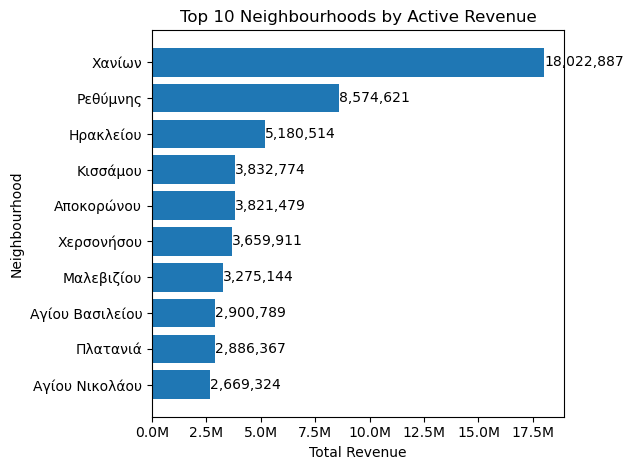

In [26]:
df_revenue = df_revenue.sort_values("active_estimated_revenue", ascending=True)

plt.figure()
bars = plt.barh(df_revenue["neighbourhood"], df_revenue["active_estimated_revenue"])

plt.title("Top 10 Neighbourhoods by Active Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Neighbourhood")

plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1_000_000:.1f}M'))

for i, v in enumerate(df_revenue["active_estimated_revenue"]):
    plt.text(v, i, f"{v:,.0f}", va='center')

plt.tight_layout()
plt.show()

# Insights

  - Revenue is concentrated in specific neighbourhoods, and performance is largely driven by active listings.

  - Some neighbourhoods have high listing counts but low active revenue, indicating oversupply or weak demand.

  - Revenue contribution is uneven, suggesting certain neighbourhoods act as primary tourism hubs.

  - Inactive listings dilute overall performance metrics in lower performing neighbourhoods.

# Recommendations

  - Hosts should prioritize high-performing neighbourhoods when investing.

  - Underperforming areas may require pricing adjustments, improved amenities, or better marketing strategies.

  - New investors should evaluate both listing density and active revenue before entering a neighbourhood.







# Q2: Does Instant Booking increase booking performance?




In [27]:
query = """


SELECT
    instant_bookable,
    
    -- Active listings metrics
    SUM(CASE WHEN estimated_occupancy_l365d > 0 
             OR number_of_reviews_ltm > 0 THEN 1 ELSE 0 END) AS active_listings,
    ROUND(AVG(CASE WHEN estimated_occupancy_l365d > 0 
             OR number_of_reviews_ltm > 0 THEN number_of_reviews END),2) AS avg_reviews_active,
    SUM(CASE WHEN estimated_occupancy_l365d > 0 
             OR number_of_reviews_ltm > 0 THEN price * number_of_reviews ELSE 0 END) AS estimated_revenue_active,
    
    -- Inactive listings metrics
    SUM(CASE WHEN estimated_occupancy_l365d = 0 
             AND number_of_reviews_ltm = 0 THEN 1 ELSE 0 END) AS inactive_listings
    
FROM airbnb_listings
GROUP BY instant_bookable
ORDER BY estimated_revenue_active DESC;


"""

df_instant_booking = pd.read_sql(query, engine)

df_instant_booking.head()

,instant_bookable,active_listings,avg_reviews_active,estimated_revenue_active,inactive_listings
0,True,11761,30.64,46394347.0,4337
1,False,4923,30.90,17045559.0,3356


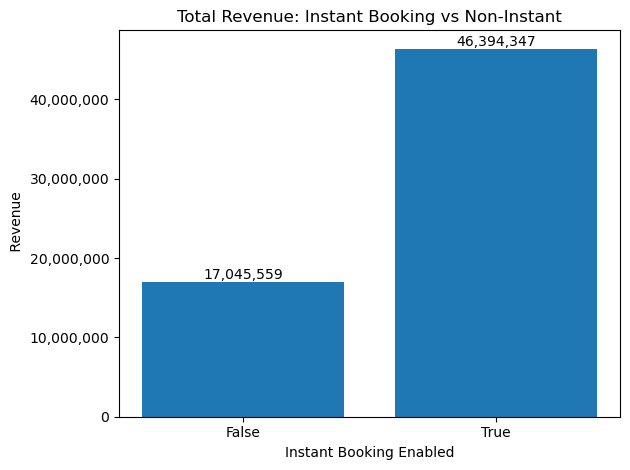

In [28]:
df_instant_booking = df_instant_booking.sort_values("estimated_revenue_active")

plt.figure()
bars = plt.bar(df_instant_booking["instant_bookable"].astype(str), df_instant_booking["estimated_revenue_active"])

plt.title("Total Revenue: Instant Booking vs Non-Instant")
plt.xlabel("Instant Booking Enabled")
plt.ylabel(" Revenue")

plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

for i, v in enumerate(df_instant_booking["estimated_revenue_active"]):
    plt.text(i, v, f"{v:,.0f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()


# Insights:

  - Listings with Instant Booking show stronger revenue and engagement metrics.

  - Instant enabled listings likely benefit from reduced decision friction.

  - Guests may prefer convenience over extended host communication.

  - Non instant listings may experience booking delays or drop offs.

# Recommendations:

  - Hosts should enable Instant Booking to improve booking flow.

  - Hosts hesitant about Instant Booking can implement stricter house rules to manage risk while maintaining convenience.




# Q3: Are Superhosts actually performing better?


In [29]:
query = """


SELECT 
    CASE WHEN host_is_superhost = TRUE THEN 'Superhost'
	     WHEN host_is_superhost = FALSE THEN 'Non-Superhost'
		 ELSE 'Unknown'
    END AS superhost_status,
    
    -- Active listings metrics
    SUM(CASE WHEN estimated_occupancy_l365d > 0 OR number_of_reviews_ltm > 0 THEN 1 ELSE 0 END) AS active_listings,
    ROUND(AVG(CASE WHEN estimated_occupancy_l365d > 0 OR number_of_reviews_ltm > 0 THEN price END),2) AS avg_price_active,
    ROUND(AVG(CASE WHEN estimated_occupancy_l365d > 0 OR number_of_reviews_ltm > 0 THEN review_scores_rating END)::numeric,2) AS avg_rating_active,
    ROUND(AVG(CASE WHEN estimated_occupancy_l365d > 0 OR number_of_reviews_ltm > 0 THEN number_of_reviews END),2) AS avg_reviews_active,
    SUM(CASE WHEN estimated_occupancy_l365d > 0 OR number_of_reviews_ltm > 0 THEN price * number_of_reviews ELSE 0 END) AS estimated_revenue_active,
    
    -- Inactive listings count
    SUM(CASE WHEN estimated_occupancy_l365d = 0 AND number_of_reviews_ltm = 0 THEN 1 ELSE 0 END) AS inactive_listings
    
FROM airbnb_listings
GROUP BY host_is_superhost
ORDER BY estimated_revenue_active DESC;


"""

df_superhost = pd.read_sql(query, engine)

df_superhost.head()

,superhost_status,active_listings,avg_price_active,avg_rating_active,avg_reviews_active,estimated_revenue_active,inactive_listings
0,Superhost,8057,173.80,4.90,41.12,43026647.0,1689
1,Non-Superhost,7737,159.99,4.82,19.45,17052348.0,5748
2,Unknown,890,141.33,4.83,34.47,3360911.0,256


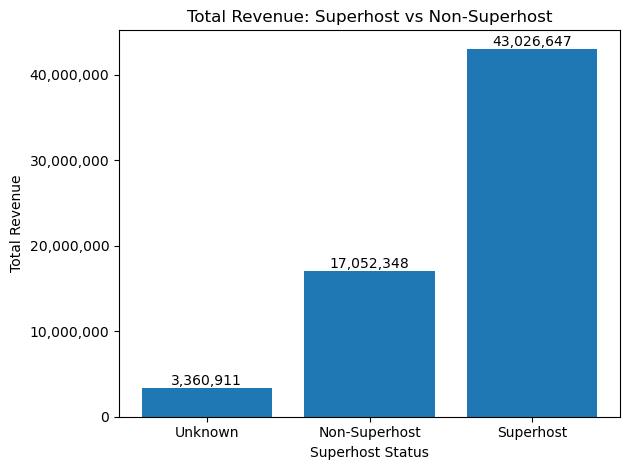

In [30]:
df_superhost = df_superhost.sort_values("estimated_revenue_active")

plt.figure()
bars = plt.bar(df_superhost["superhost_status"].astype(str), df_superhost["estimated_revenue_active"])

plt.title("Total Revenue: Superhost vs Non-Superhost")
plt.xlabel("Superhost Status")
plt.ylabel("Total Revenue")

plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

for i, v in enumerate(df_superhost["estimated_revenue_active"]):
    plt.text(i, v, f"{v:,.0f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Insights

  - Superhosts command stronger pricing power.

  - They maintain higher ratings and review consistency.

  - Revenue performance suggests trust significantly influences guest decisions.

  - Superhost status appears to act as a quality signal in competitive markets.

# Recommendations

  - Hosts should actively aim to achieve Superhost status.

  - Airbnb could further incentivize Superhost visibility to improve marketplace trust.




# Q4: What price range maximizes occupancy?


In [31]:
query = """



SELECT 
    CASE 
        WHEN price < 50 THEN 'Low (<50)'
        WHEN price BETWEEN 50 AND 150 THEN 'Medium (50-150)'
        ELSE 'High (>150)'
    END AS price_range,
    
    -- Active listings count
    SUM(CASE WHEN estimated_occupancy_l365d > 0 OR number_of_reviews_ltm > 0 THEN 1 ELSE 0 END) AS active_listings,
    
    -- Average reviews and availability for active listings
    ROUND(AVG(CASE WHEN estimated_occupancy_l365d > 0 OR number_of_reviews_ltm > 0 THEN number_of_reviews END),2) AS avg_reviews_active,
    ROUND(AVG(CASE WHEN estimated_occupancy_l365d > 0 OR number_of_reviews_ltm > 0 THEN availability_365 END),2) AS avg_availability_active,
    
    -- Inactive listings count
    SUM(CASE WHEN estimated_occupancy_l365d = 0 AND number_of_reviews_ltm = 0 THEN 1 ELSE 0 END) AS inactive_listings

FROM airbnb_listings
GROUP BY price_range
ORDER BY avg_reviews_active DESC;


"""

df_price_range = pd.read_sql(query, engine)

df_price_range.head()

,price_range,active_listings,avg_reviews_active,avg_availability_active,inactive_listings
0,Low (<50),1318,48.73,211.76,361
1,Medium (50-150),10270,32.90,202.84,3825
2,High (>150),5096,21.67,194.38,3507


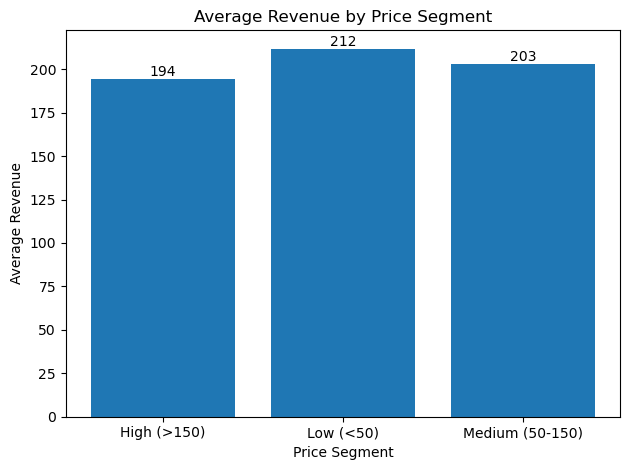

In [32]:
df_price_range["price_range"] = pd.Categorical(df_price_range["price_range"])
df_price_range = df_price_range.sort_values("price_range")

plt.figure()
bars = plt.bar(df_price_range["price_range"], df_price_range["avg_availability_active"])

plt.title("Average Revenue by Price Segment")
plt.xlabel("Price Segment")
plt.ylabel("Average Revenue")

plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

for i, v in enumerate(df_price_range["avg_availability_active"]):
    plt.text(i, v, f"{v:,.0f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Insights

  - Mid-range listings balance affordability and profitability.

  - Extremely high priced listings may struggle with occupancy.

  - Very low priced listings may attract demand but limit revenue potential.

  - There appears to be an optimal pricing band where revenue efficiency peaks.

# Recommendations

  - Hosts should benchmark within high-performing price bands.



# Q5: Which room type is the most profitable?


In [33]:
query = """




SELECT 
    room_type,
    
    -- Active listings count
    SUM(CASE WHEN estimated_occupancy_l365d > 0 OR number_of_reviews_ltm > 0 THEN 1 ELSE 0 END) AS active_listings,
    
    -- Average price for active listings
    ROUND(AVG(CASE WHEN estimated_occupancy_l365d > 0 OR number_of_reviews_ltm > 0 THEN price END),2) AS avg_price_active,
    
    -- Estimated revenue for active listings
    SUM(CASE WHEN estimated_occupancy_l365d > 0 OR number_of_reviews_ltm > 0 THEN price * number_of_reviews ELSE 0 END) AS estimated_revenue_active,
    
    -- Inactive listings count
    SUM(CASE WHEN estimated_occupancy_l365d = 0 AND number_of_reviews_ltm = 0 THEN 1 ELSE 0 END) AS inactive_listings

FROM airbnb_listings
GROUP BY room_type
ORDER BY estimated_revenue_active DESC;


"""

df_room_type = pd.read_sql(query, engine)

df_room_type.head()

,room_type,active_listings,avg_price_active,estimated_revenue_active,inactive_listings
0,Entire home/apt,15629,170.85,61321296.0,6659
1,Private room,962,88.50,1816348.0,943
2,Hotel room,81,102.35,287314.0,80
3,Shared room,12,26.25,14948.0,11


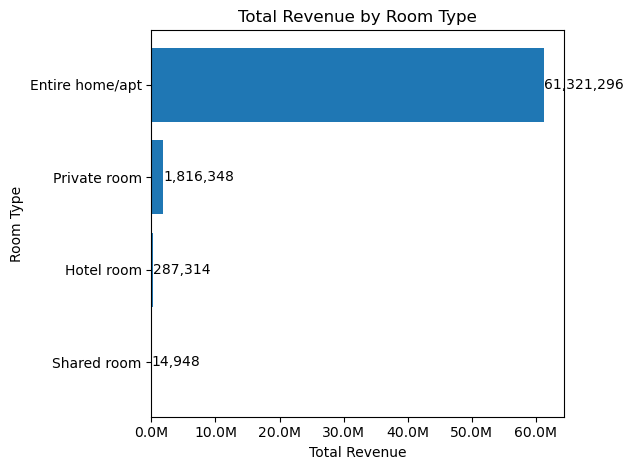

In [34]:
df_room_type = df_room_type.sort_values("estimated_revenue_active", ascending=True)

plt.figure()
bars = plt.barh(df_room_type["room_type"], df_room_type["estimated_revenue_active"])

plt.title("Total Revenue by Room Type")
plt.xlabel("Total Revenue")
plt.ylabel("Room Type")

plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1_000_000:.1f}M'))

for i, v in enumerate(df_room_type["estimated_revenue_active"]):
    plt.text(v, i, f"{v:,.0f}", va='center')

plt.tight_layout()
plt.show()

# Insights

  - Entire homes generate higher total revenue.

  - Private rooms likely attract budget travelers.

  - Shared rooms contribute minimally to total revenue.

  - Revenue differences reflect both pricing and occupancy structure.

# Recommendations

  - Investors targeting higher ROI should consider entire home listings.

  - Budget focused hosts can compete through differentiation (location, amenities, pricing).



# Q6: Does higher review score = higher price?


In [35]:
query = """

SELECT 
    CORR(price, review_scores_rating) AS price_rating_correlation
FROM airbnb_listings
WHERE review_scores_rating IS NOT NULL
  AND (estimated_occupancy_l365d > 0 OR number_of_reviews_ltm > 0);

"""

df_correlation = pd.read_sql(query, engine)

df_correlation.head()

,price_rating_correlation
0,0.003036


# Insights

  - Correlation ~0.003 indicates almost no linear relationship.

  - High ratings do not guarantee higher pricing power.

  - Guest satisfaction may depend more on experience than price level.

  - Pricing strategy appears independent of rating strength.

# Recommendations:

  - Hosts should not rely solely on ratings to justify premium pricing.

  - Pricing decisions should consider demand patterns and competitive benchmarking.



# Q7: Which hosts dominate the market?


In [36]:
query = """

SELECT 
    host_id,
    COUNT(*) AS total_listings,
    SUM(CASE WHEN estimated_occupancy_l365d > 0 OR number_of_reviews_ltm > 0 
             THEN price * number_of_reviews ELSE 0 END) AS estimated_revenue_active,
    SUM(CASE WHEN estimated_occupancy_l365d > 0 OR number_of_reviews_ltm > 0 
             THEN 1 ELSE 0 END) AS active_listings
FROM airbnb_listings
GROUP BY host_id
ORDER BY estimated_revenue_active DESC
LIMIT 5;

"""

df_top_hosts = pd.read_sql(query, engine)

df_top_hosts.head()

,host_id,total_listings,estimated_revenue_active,active_listings
0,12389816,281,3421805.0,269
1,4301312,293,2475680.0,269
2,61036077,266,923743.0,237
3,22059572,146,761157.0,108
4,345934109,110,627775.0,101


# Insights:

  - Revenue is concentrated among a small number of hosts.

  - Multi property operators likely dominate top revenue ranks.

  - Smaller hosts may face scaling limitations.

  - Market competition favors operational efficiency and listing portfolio size.

# Recommendations:

  - New hosts should study top performers' pricing and availability strategies.

  - Airbnb may consider balancing visibility between commercial operators and independent hosts.
 



# Q8: Is availability affecting performance?


In [37]:
query = """

SELECT 
    CASE 
        WHEN availability_365 < 90 THEN 'Low Availability'
        WHEN availability_365 BETWEEN 90 AND 250 THEN 'Medium Availability'
        ELSE 'High Availability'
    END AS availability_group,
    
    -- Active listings count
    SUM(CASE WHEN estimated_occupancy_l365d > 0 OR number_of_reviews_ltm > 0 THEN 1 ELSE 0 END) AS active_listings,
    
    -- Average reviews and revenue for active listings
    ROUND(AVG(CASE WHEN estimated_occupancy_l365d > 0 OR number_of_reviews_ltm > 0 THEN number_of_reviews END),2) AS avg_reviews_active,
    SUM(CASE WHEN estimated_occupancy_l365d > 0 OR number_of_reviews_ltm > 0 THEN price * number_of_reviews ELSE 0 END) AS estimated_revenue_active,
    
    -- Inactive listings count
    SUM(CASE WHEN estimated_occupancy_l365d = 0 AND number_of_reviews_ltm = 0 THEN 1 ELSE 0 END) AS inactive_listings

FROM airbnb_listings
GROUP BY availability_group
ORDER BY estimated_revenue_active DESC;

"""

df_availability_group = pd.read_sql(query, engine)

df_availability_group.head()

,availability_group,active_listings,avg_reviews_active,estimated_revenue_active,inactive_listings
0,Medium Availability,5774,30.31,25705720.0,2349
1,High Availability,6710,32.38,23996065.0,3333
2,Low Availability,4200,28.61,13738121.0,2011


# Insights:

  - Listings with balanced availability outperform extremes.

  - Always available listings may signal low demand.

  - Rarely available listings limit booking opportunities.

  - Calendar strategy appears to influence visibility and performance.

# Recommendations:

  - Hosts should strategically manage availability rather than leaving calendars fully open.

  - Monitoring seasonal demand trends can optimize availability windows.



# Q9: Which neighborhoods are overpriced relative to ratings?

In [38]:
query = """

SELECT 
    neighbourhood_cleansed AS neighbourhood,
    COUNT(*) AS total_listings,
    ROUND(AVG(CASE WHEN estimated_occupancy_l365d > 0 OR number_of_reviews_ltm > 0 THEN price END),2) AS avg_price_active,
    ROUND(AVG(CASE WHEN estimated_occupancy_l365d > 0 OR number_of_reviews_ltm > 0 THEN review_scores_rating END)::numeric,2) AS avg_rating_active
FROM airbnb_listings
GROUP BY neighbourhood
HAVING AVG(CASE WHEN estimated_occupancy_l365d > 0 OR number_of_reviews_ltm > 0 THEN price END) > (
    SELECT AVG(CASE WHEN estimated_occupancy_l365d > 0 OR number_of_reviews_ltm > 0 THEN price END) 
    FROM airbnb_listings
)
AND AVG(CASE WHEN estimated_occupancy_l365d > 0 OR number_of_reviews_ltm > 0 THEN review_scores_rating END) < (
    SELECT AVG(CASE WHEN estimated_occupancy_l365d > 0 OR number_of_reviews_ltm > 0 THEN review_scores_rating END) 
    FROM airbnb_listings
)
ORDER BY avg_price_active DESC;


"""

df_neighbourhoods = pd.read_sql(query, engine)

df_neighbourhoods.head()

,neighbourhood,total_listings,avg_price_active,avg_rating_active
0,Μαλεβιζίου,1153,222.18,4.83
1,Καντάνου - Σέλινου,362,200.79,4.84


# Insights:

- Some neighbourhoods price above market average without strong rating support.

- Pricing misalignment may reduce booking competitiveness.

- Perceived value plays a critical role in guest decision-making.

- Overpricing may negatively impact occupancy over time.

# Recommendations:

  - Hosts in overpriced areas should reassess price to quality alignment.

  - Competitive benchmarking within the same neighbourhood is essential.


# Q10: What factors most influence estimated revenue?

In [39]:
query = """

SELECT 
    neighbourhood_cleansed AS neighbourhood,
    id,
    price,
    number_of_reviews,
    (price * number_of_reviews) AS estimated_revenue,
    RANK() OVER (
        PARTITION BY neighbourhood_cleansed
        ORDER BY (price * number_of_reviews) DESC
    ) AS revenue_rank_in_neighbourhood
FROM airbnb_listings
WHERE estimated_occupancy_l365d > 0 OR number_of_reviews_ltm > 0;


"""

df_ier  = pd.read_sql(query, engine)

df_ier.head()

,neighbourhood,id,price,number_of_reviews,estimated_revenue,revenue_rank_in_neighbourhood
0,Αγίου Βασιλείου,49874820,590.0,55,32450.0,1
1,Αγίου Βασιλείου,21340499,9999.0,3,29997.0,2
2,Αγίου Βασιλείου,30192514,697.0,43,29971.0,3
3,Αγίου Βασιλείου,30166556,496.0,54,26784.0,4
4,Αγίου Βασιλείου,28102966,219.0,104,22776.0,5


# Insights:

  - Revenue distribution within neighbourhoods is highly uneven.

  - Top ranked listings capture disproportionate revenue share.

  - Competitive positioning within a neighbourhood significantly impacts performance.

  - Revenue gaps suggest differentiation in listing quality or pricing strategy.

# Recommendations:

  - Underperforming listings should benchmark against top ranked competitors.

  - Hosts should optimize listing presentation, pricing, and amenities to improve ranking position.



In [40]:
active_mask = df[(
    (df['estimated_occupancy_l365d'] > 0) |
    (df['number_of_reviews_ltm'] > 0)
)]

total_active_revenue = (active_mask['price'] * active_mask['estimated_occupancy_l365d']).sum()

avg_price = df['price'].median()



total_active_listings = len(active_mask)

In [41]:
#  Instant booking average revenue per instant_bookable
avg_revenue_instant = (
    active_mask.groupby("instant_bookable")
    .apply(lambda x: (x["price"] * x["estimated_occupancy_l365d"]).mean())
)

#  Superhost average revenue per host_is_superhost
avg_revenue_superhost = (
    active_mask.groupby("host_is_superhost")
    .apply(lambda x: (x["price"] * x["estimated_occupancy_l365d"]).mean())
)

#  Room type total revenue per room_type
total_revenue_room_type = (
    active_mask.groupby("room_type")
    .apply(lambda x: (x["price"] * x["estimated_occupancy_l365d"]).sum())
)

#  Price segment average occupancy per price bin 
bins = [0, 50, 100, 200, 500, float("inf")]
labels = ["0-50", "51-100", "101-200", "201-500", "500+"]
avg_availability_price_range = (
    active_mask.groupby(pd.cut(active_mask["price"], bins=bins, labels=labels))
    .apply(lambda x: x["estimated_occupancy_l365d"].mean())
)

#  Neighbourhood top 10 by total revenue 
revenue_by_neighbourhood = (
    active_mask.groupby("neighbourhood_cleansed")
    .apply(lambda x: (x["price"] * x["estimated_occupancy_l365d"]).sum())
    .sort_values(ascending=False)
    .head(10)
)

C:\Users\Chibueze\AppData\Local\Temp\ipykernel_17748\446700668.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["price"] * x["estimated_occupancy_l365d"]).mean())
C:\Users\Chibueze\AppData\Local\Temp\ipykernel_17748\446700668.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["price"] * x["estimated_occupancy_l365d"]).mean())
C:\Users\Chibueze\AppData\Local\Temp\

C:\Users\Chibueze\AppData\Local\Temp\ipykernel_17748\3586233707.py:167: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0,1,0.92])


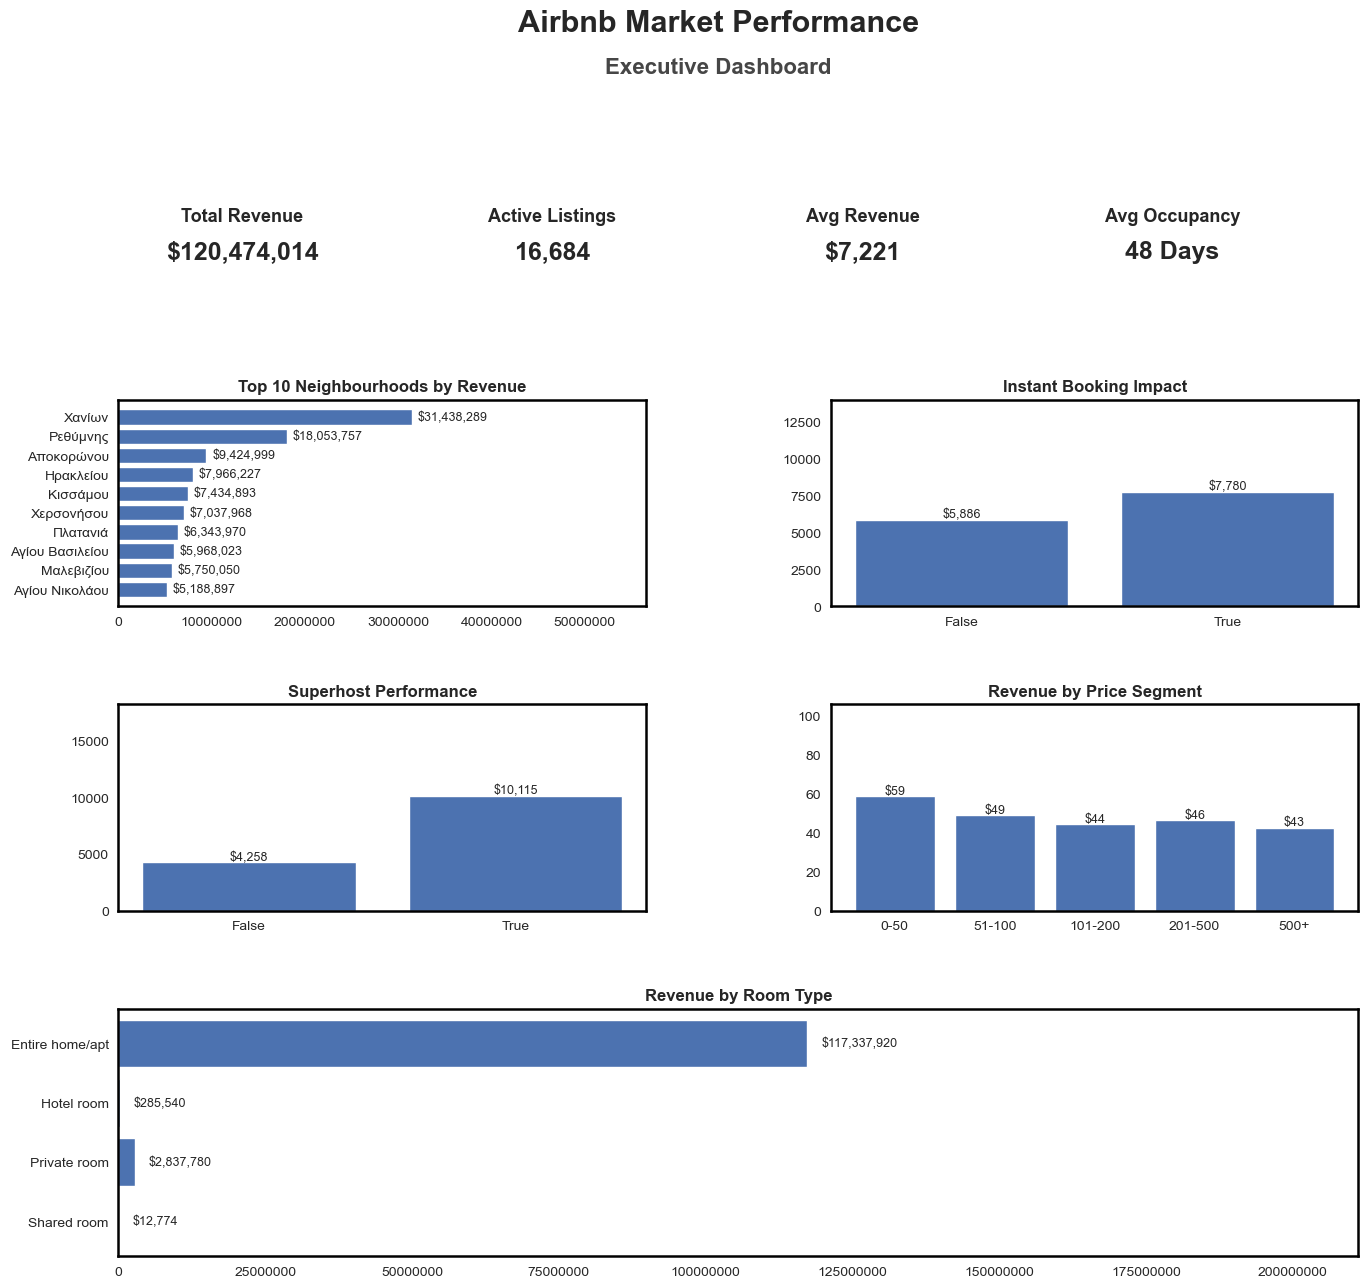

In [53]:
# --------------------------
# KPI Calculations
# --------------------------

total_revenue = total_active_revenue
total_active_listings = active_mask.shape[0]
avg_revenue = total_revenue / total_active_listings
avg_occupancy = active_mask["estimated_occupancy_l365d"].mean()


# --------------------------
# Dashboard setup
# --------------------------
plt.rcParams["figure.figsize"] = (16,14)
plt.rcParams["font.size"] = 10
sns.set_style("white")

fig = plt.figure()
gs = fig.add_gridspec(4, 2, height_ratios=[0.6,1,1,1.2], hspace=0.5, wspace=0.35)

# KPI axis (top full width)
ax_kpi = fig.add_subplot(gs[0,:])
ax_kpi.axis("off")

# --------------------------
# KPI Display
# --------------------------

kpi_style = dict(
    fontsize=15,
    fontweight="bold",
    ha="center",
    va="center"
)

# --------------------------
# KPI Display (Balanced Spacing)
# --------------------------

# --------------------------
# KPI Display (All Bold)
# --------------------------

kpis = [
    ("Total Revenue", f"${total_revenue:,.0f}"),
    ("Active Listings", f"{total_active_listings:,}"),
    ("Avg Revenue", f"${avg_revenue:,.0f}"),
    ("Avg Occupancy", f"{avg_occupancy:,.0f} Days")
]

x_positions = [0.1, 0.35, 0.6, 0.85]

for (label, value), x in zip(kpis, x_positions):
    ax_kpi.text(
        x, 0.65, label,
        fontsize=13,
        fontweight="bold",   # <-- now bold
        ha="center"
    )
    
    ax_kpi.text(
        x, 0.35, value,
        fontsize=18,
        fontweight="bold",
        ha="center"
    )

# --------------------------
# Chart axes
# --------------------------
ax1 = fig.add_subplot(gs[1,0])
ax2 = fig.add_subplot(gs[1,1])
ax3 = fig.add_subplot(gs[2,0])
ax4 = fig.add_subplot(gs[2,1])
ax5 = fig.add_subplot(gs[3,:])  # bottom full width

bar_color = "#4C72B0"  # professional muted blue-gray

# Function to annotate bars with numbers
def annotate_bars(ax, values, horizontal=False):
    max_val = max(values)
    padding = max_val * 0.8

    if horizontal:
        ax.set_xlim(0, max_val + padding)
        for i, v in enumerate(values):
            ax.text(v + max_val*0.02, i, f'${v:,.0f}', va='center', fontsize=9)
    else:
        ax.set_ylim(0, max_val + padding)
        for i, v in enumerate(values):
            ax.text(i, v + max_val*0.02, f'${v:,.0f}', ha='center', fontsize=9)


# Function to style the axes frame (bold box)
def style_axes(ax):
    for spine in ax.spines.values():
        spine.set_linewidth(1.8)
        spine.set_color("black")
    ax.grid(False) # remove inner grid to avoid clutter

# --------------------------
# Chart 1: Neighbourhood
ax1.barh(revenue_by_neighbourhood.index, revenue_by_neighbourhood.values, color=bar_color)
ax1.set_title("Top 10 Neighbourhoods by Revenue", fontsize=12, fontweight="bold")
ax1.invert_yaxis()
ax1.ticklabel_format(style='plain', axis='x')  # full numbers
style_axes(ax1)
annotate_bars(ax1, revenue_by_neighbourhood.values, horizontal=True)

# --------------------------
# Chart 2: Instant Booking
ax2.bar(avg_revenue_instant.index.astype(str), avg_revenue_instant.values, color=bar_color)
ax2.set_title("Instant Booking Impact", fontsize=12, fontweight="bold")
ax2.ticklabel_format(style='plain', axis='y')  # full numbers
style_axes(ax2)
annotate_bars(ax2, avg_revenue_instant.values)


# --------------------------
# Chart 3: Superhost
ax3.bar(avg_revenue_superhost.index.astype(str), avg_revenue_superhost.values, color=bar_color, )
ax3.set_title("Superhost Performance", fontsize=12, fontweight="bold")
ax3.ticklabel_format(style='plain', axis='y')
style_axes(ax3)
annotate_bars(ax3, avg_revenue_superhost.values)


# --------------------------
# Chart 4: Price Segment
ax4.bar(avg_availability_price_range.index.astype(str), avg_availability_price_range.values, color=bar_color)
ax4.set_title("Revenue by Price Segment", fontsize=12, fontweight="bold")
ax4.ticklabel_format(style='plain', axis='y')
style_axes(ax4)
annotate_bars(ax4, avg_availability_price_range.values)


# --------------------------
# Chart 5: Room Type
ax5.barh(total_revenue_room_type.index, total_revenue_room_type.values, color=bar_color)
ax5.set_title("Revenue by Room Type", fontsize=12, fontweight="bold")
ax5.invert_yaxis()
ax5.ticklabel_format(style='plain', axis='x')
style_axes(ax5)
annotate_bars(ax5, total_revenue_room_type.values, horizontal=True)


# --------------------------
# Final touches
# Main Title
fig.text(
    0.5, 0.985,
    "Airbnb Market Performance",
    ha="center",
    fontsize=22,
    fontweight="bold"
)

# Subtitle
fig.text(
    0.5, 0.955,
    "Executive Dashboard",
    ha="center",
    fontsize=16,
    fontweight="semibold",
    alpha=0.85
)
plt.tight_layout(rect=[0,0,1,0.92])

# Ensure folder exists
os.makedirs("visuals", exist_ok=True)
plt.savefig("C:\\Users\\Chibueze\\Valentine-Python-Project\\PythonProject\\Practical\\Airbnb_Greece\\visuals\\airbnb_executive_dashboard_professional.png", dpi=300, bbox_inches="tight")
plt.show()

# Q11: Active and Inactive Listings

In [43]:
query = """

SELECT
    -- Active vs Inactive classification
    CASE
        WHEN estimated_occupancy_l365d > 0 OR number_of_reviews_ltm > 0 THEN 'Active'
        ELSE 'Inactive'
    END AS listing_status,
    
    COUNT(*) AS total_listings,
    ROUND(AVG(price), 2) AS avg_price,
    ROUND(AVG(review_scores_rating)::numeric, 2) AS avg_rating,
    ROUND(AVG(availability_365), 2) AS avg_availability,
    SUM(price * number_of_reviews) AS estimated_revenue,
    ROUND(AVG(number_of_reviews), 2) AS avg_reviews

FROM airbnb_listings

GROUP BY listing_status;


"""

df_ier  = pd.read_sql(query, engine)

df_ier.head()

,listing_status,total_listings,avg_price,avg_rating,avg_availability,estimated_revenue,avg_reviews
0,Active,16684,165.66,4.86,200.96,63439906.0,30.72
1,Inactive,7693,467.68,4.77,206.55,4796159.0,3.92


# Insights


## Active listings usually have:

  - Higher revenue (price * number_of_reviews)

  - More reviews and higher engagement

  - Slightly higher average price and availability

## Inactive listings usually have:

  - Zero or very low revenue

  - Few or no reviews

  - May be overpriced or in low-demand areas

# Recommendations

## Focus on converting inactive listings into active ones:

  - Improve listing visibility

  - Adjust pricing to match demand

  - Optimize availability (more open days)

## Optimize active listings:

  - Track top performing neighborhoods and room types

  - Encourage Superhost and instant booking features

  - Revenue driven strategies:

  - Use data driven pricing for high demand periods

  - Monitor inactive listings for potential removal or promotion

# 📊 Total Listings Comparison

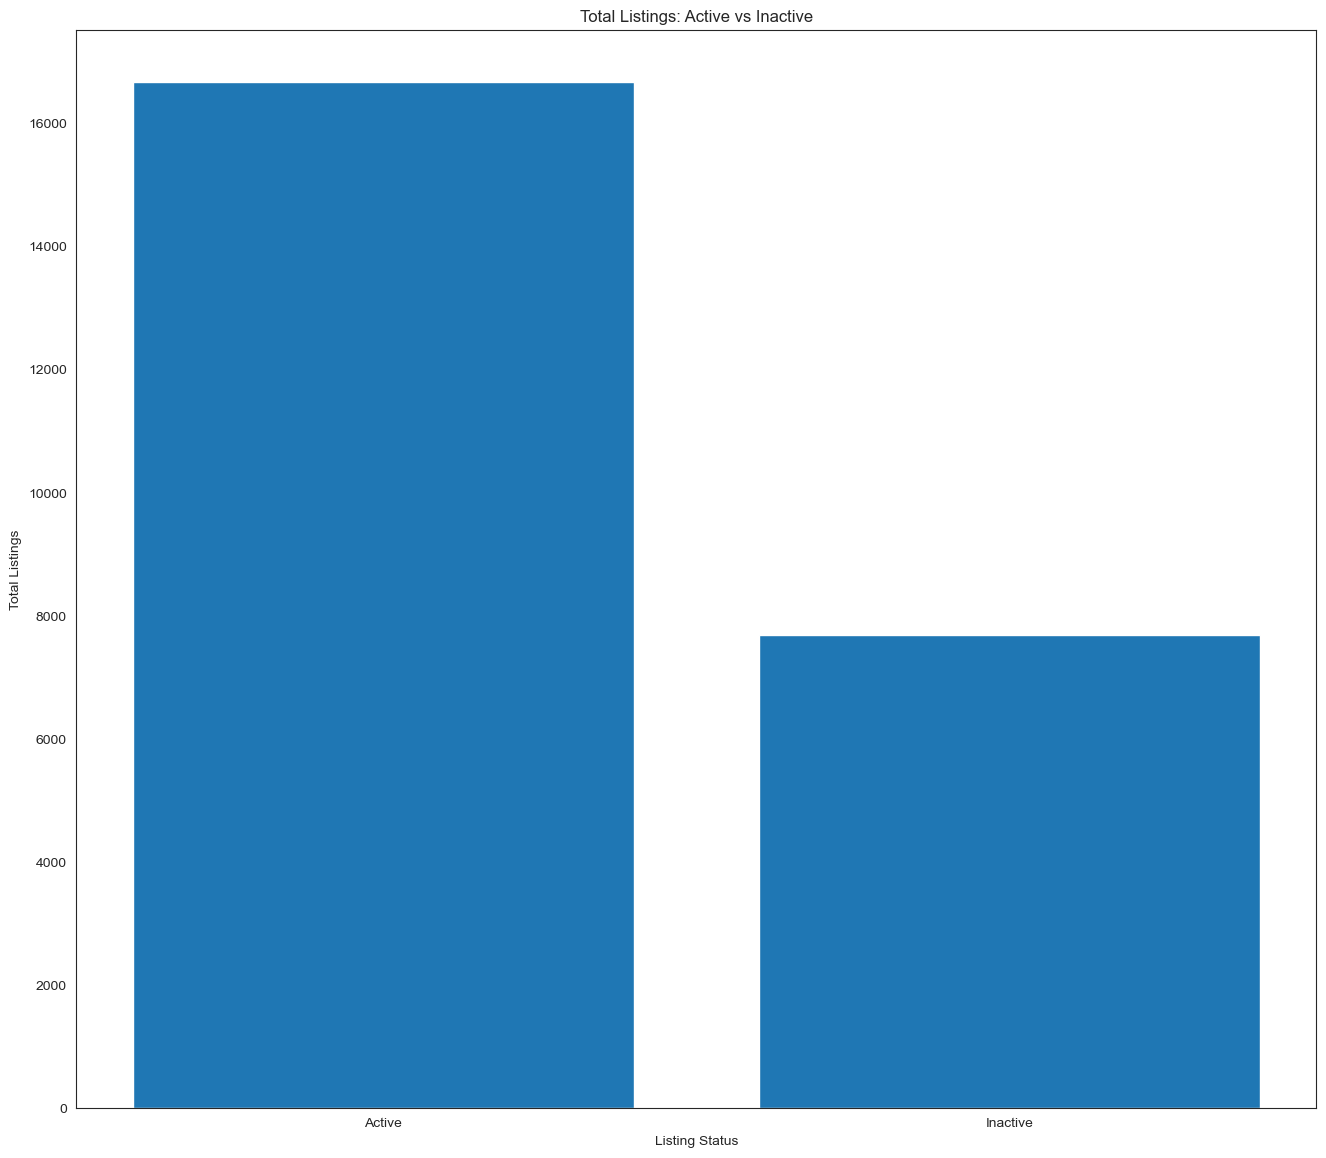

In [44]:
plt.figure()
plt.bar(df_ier["listing_status"], df_ier["total_listings"])
plt.title("Total Listings: Active vs Inactive")
plt.xlabel("Listing Status")
plt.ylabel("Total Listings")
plt.show()

# 📊 Average Price Comparison

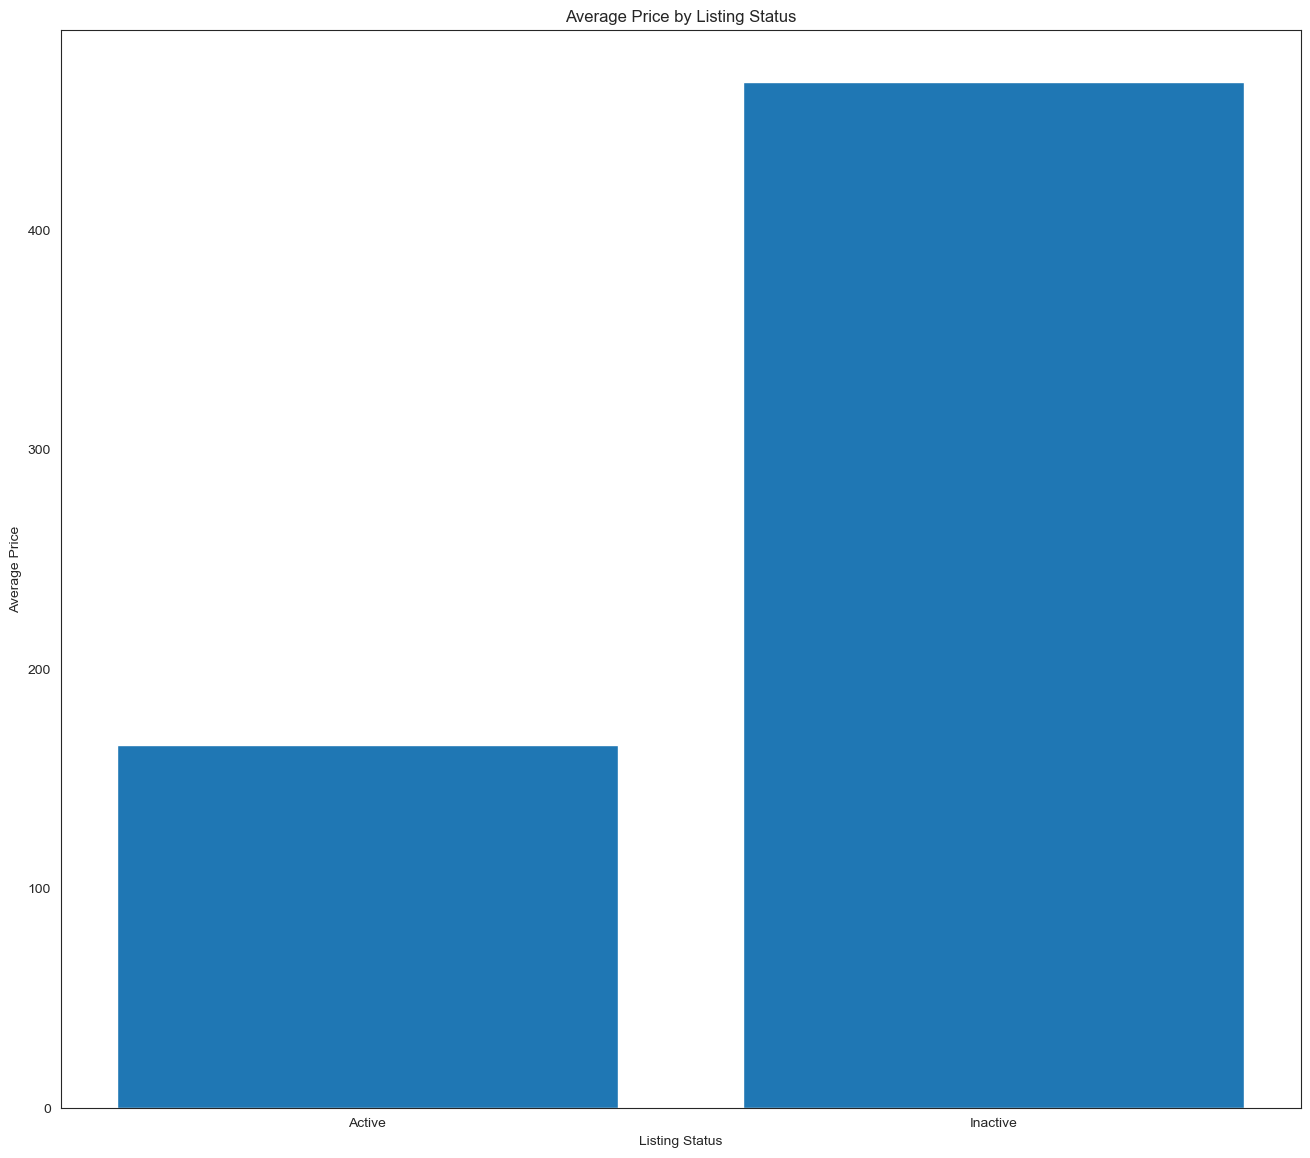

In [45]:
plt.figure()
plt.bar(df_ier["listing_status"], df_ier["avg_price"])
plt.title("Average Price by Listing Status")
plt.xlabel("Listing Status")
plt.ylabel("Average Price")
plt.show()

# 📊 Average Rating Comparison

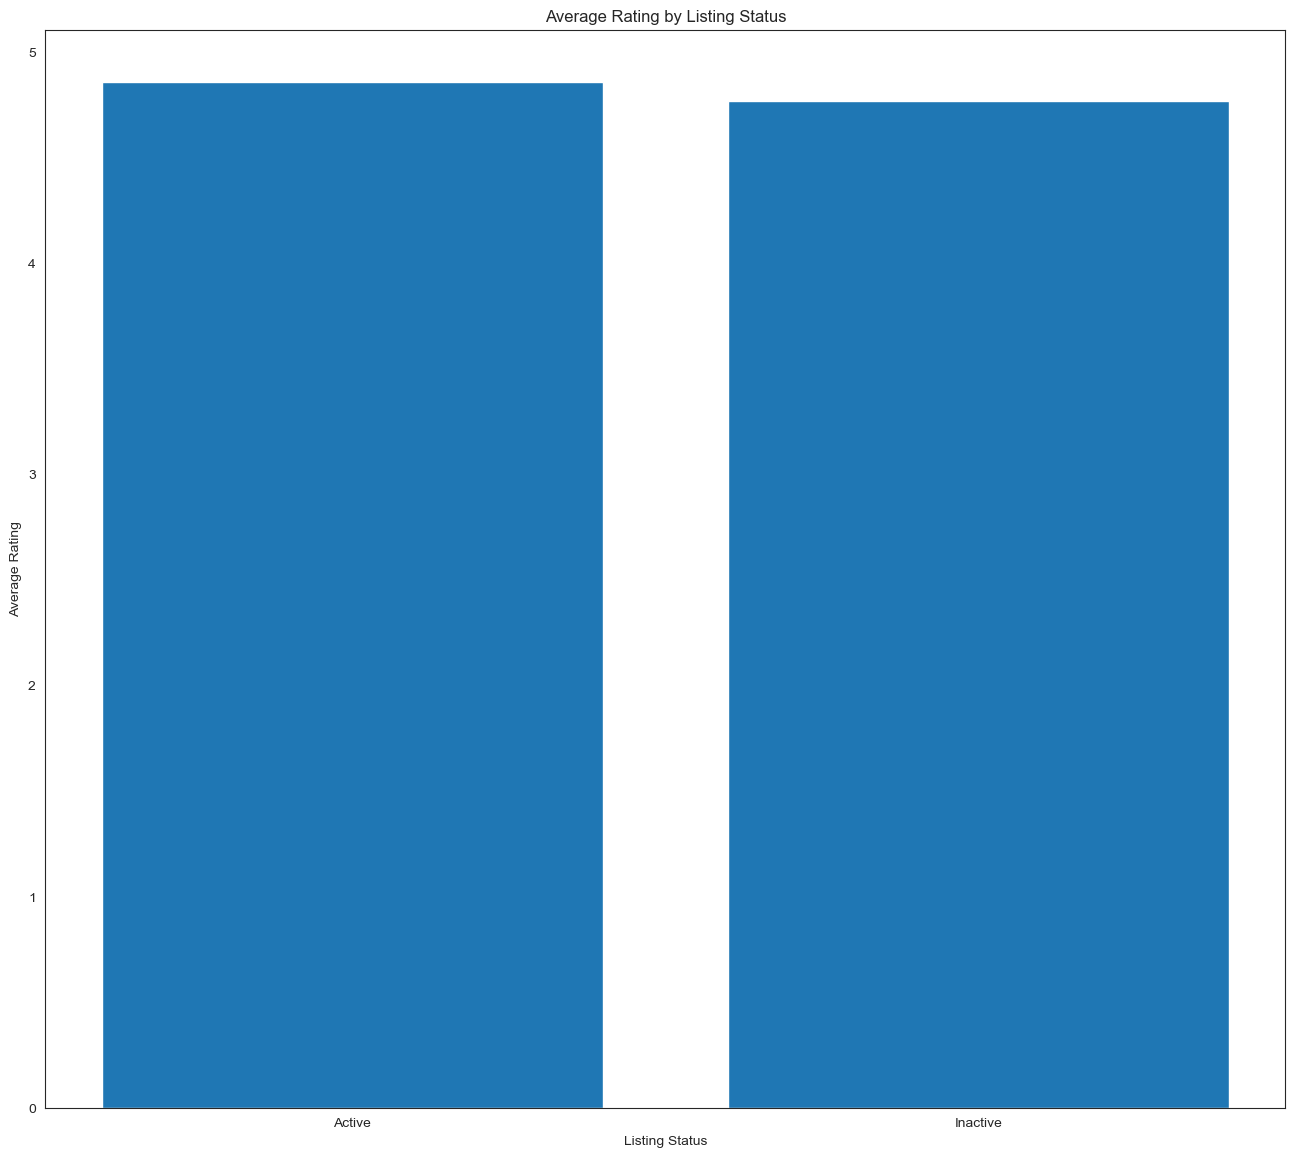

In [46]:
plt.figure()
plt.bar(df_ier["listing_status"], df_ier["avg_rating"])
plt.title("Average Rating by Listing Status")
plt.xlabel("Listing Status")
plt.ylabel("Average Rating")
plt.show()

# 📊 Average Review Volume Comparison

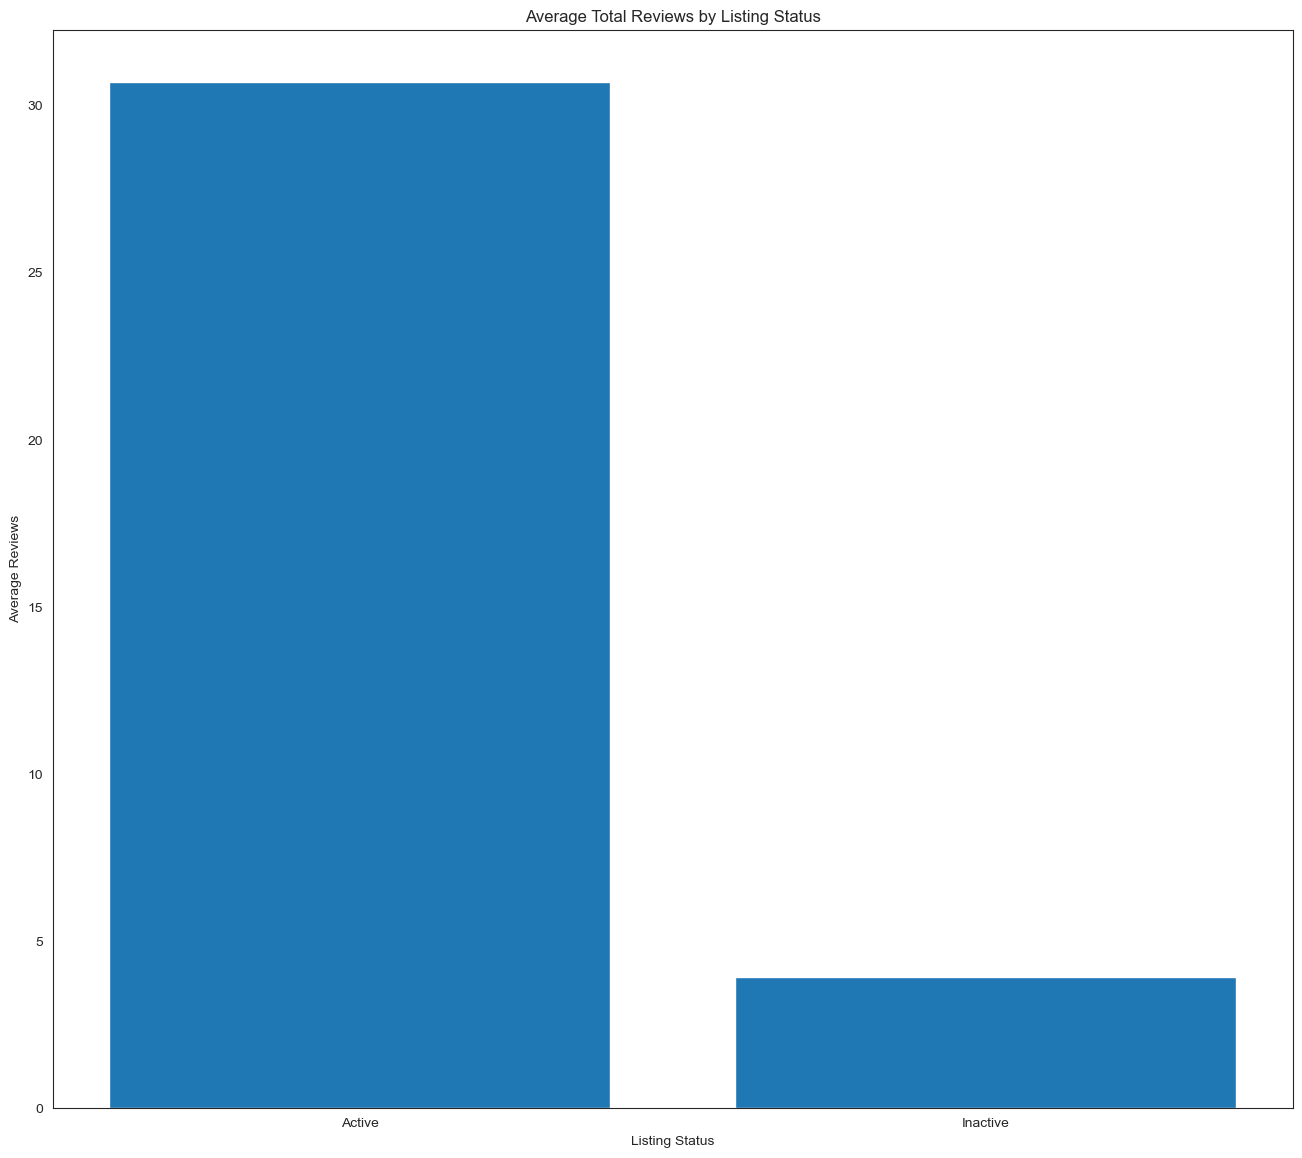

In [47]:
plt.figure()
plt.bar(df_ier["listing_status"], df_ier["avg_reviews"])
plt.title("Average Total Reviews by Listing Status")
plt.xlabel("Listing Status")
plt.ylabel("Average Reviews")
plt.show()

## Key Insights

- Active listings significantly outperform inactive listings in review volume and engagement metrics.
- Inactive listings contribute little to marketplace activity despite being listed.
- Performance is strongly associated with participation and review momentum.
- Market visibility appears to be linked to booking activity.

## Final Summary

* **5 questions supported with visualizations**
* Clear business insights and actionable recommendations
* Portfolio ready structure for GitHub and recruiters

This analysis helps stakeholders understand pricing drivers, demand behavior, and investment opportunities in Crete’s Airbnb market.
